# Прикладные задачи машинного обучения, DS-поток
## Задание 3

**Правила:**

* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Выполненную работу нужно отправить телеграм-боту `@miptstats_ds24_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайны см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания все участники списывания получат штраф.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*
* В каждой задаче не забывайте делать **пояснения и выводы**.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.


**Правила оформления теоретических задач:**

* Решения необходимо прислать одним из следующих способов:
  * фотографией в правильной ориентации, где все четко видно, а почерк разборчив,
    * отправив ее как файл боту вместе с ноутбуком *или*
    * вставив ее в ноутбук посредством `Edit -> Insert Image` (<font color="red">фото, вставленные ссылкой, не принимаются</font>);
  * в виде $\LaTeX$ в markdown-ячейках.
* Решения не проверяются, если какое-то требование не выполнено. Особенно внимательно все проверьте в случае выбора второго пункта (вставки фото в ноутбук). <font color="red"><b>Неправильно вставленные фотографии могут не передаться при отправке.</b></font> Для проверки попробуйте переместить `ipynb` в другую папку и открыть его там.
* В решениях поясняйте, чем вы пользуетесь, хотя бы кратко. Например, если пользуетесь независимостью, то достаточно подписи вида "*X и Y незав.*"
* Решение, в котором есть только ответ, и отсутствуют вычисления, оценивается в 0 баллов.



**Баллы за задание:**

* Задача 1 &mdash; 20 баллов
* Задача 2 &mdash; 180 баллов

-----------

In [1]:
# Bot check

# HW_ID: ds_ml2_3
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: not final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [2]:
import multiprocessing as mp
try:
    mp.set_start_method('spawn', force=True)
except RuntimeError:
    pass

In [3]:
import os
import sys

if 'google.colab' in sys.modules:
    !pip install swig
    !pip install 'gymnasium[all]' pyglet pygame multiprocess
    !apt-get install -y xvfb python-opengl > /dev/null 2>&1
    !pip install 'gymnasium[atari]' 'gymnasium[accept-rom-license]'
    !pip install ffmpeg
    !pip install imageio-ffmpeg

# XVFB will be launched if you run on a server
import os
if type(os.environ.get('DISPLAY')) is not str or len(os.environ.get('DISPLAY')) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'


bash: ../xvfb: No such file or directory


In [4]:
from __future__ import division, print_function

import os
import gc
from collections import defaultdict

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from gymnasium.wrappers import RecordVideo
from IPython.core import display
from IPython.display import clear_output
from pandas import DataFrame
from torch.autograd import Variable
from torch.distributions import Categorical
from tqdm import trange


device = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
# В torch 2.2.0 для GPU Apple silicon всё ещё не поддерживается одна из необходимых далее операций: aten::linalg_qr.out
# Так что если у вас мак, то советую сразу начинать делать задание в колабе

import ale_py
gym.register_envs(ale_py)

---
### Задача 1.

Пусть $P_\theta$ &mdash; семейство абсолютно непрерывных распределений на $\mathcal{X}$ с плотностями $p_\theta$, $\theta \in \Theta$; $f: \mathcal{X} \to \mathbb{R}$ &mdash; измеримая функция. Доказать, что 
$$\nabla_\theta \mathsf{E}_{P_\theta} f(X) = \mathsf{E}_{P_\theta} f(X) \nabla_\theta \log p_\theta(X).$$

$\square$

$$
\begin{align*}
\nabla_\theta \mathsf{E}_{P_\theta} f(X) &= \nabla_\theta \int f(x) p_{\theta}(x)dx = \int f(x) \nabla_{\theta} p_{\theta}(x)dx \\
&= \int f(x) \frac{p_{\theta}(x)}{p_{\theta}(x)}\nabla_{\theta} p_{\theta}(x)dx = \int f(x) p_{\theta}(x) \nabla_{\theta} \log(p_{\theta}(x))dx \\
&= \mathsf{E}_{P_\theta} f(X) \nabla_\theta \log p_\theta(X)
\end{align*}
$$


$\blacksquare$

---
### Задача 2.

В данной работе вы построите A2C агента, который должен научиться играть в PACMAN!


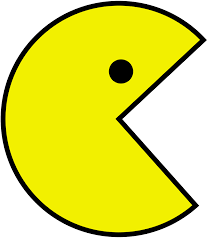

Скачаем полезные питоновские библиотеки для gym environments, которые позволят реализовать параллельную игру из нескольких сессий.

* `atari_wrappers` &mdash; библиотека для преобразования состояния, переданного `gymnasium` средой, в более удобный для работы вид. К примеру: скейлинг картинки состояния; ставить флаг `done`, если умер агент в игре; начинать с рандомных действий в начале каждой игры для лучшего обучения агента и т.п. Также в ней реализован класс `nature_dqn_env`, позволяющий параллельно играть несколько сессий.

* `env_batch` &mdash; файл-помощник для `atari_wrappers`. Нужен для реализации параллельных игр.

* `runners` &mdash; библиотека, в которой реализован `EnvRunner`. который будет играть агентом на параллельных средах, при этом на каждом шаге он будет возвращать частичную траекторию на `n_steps` шагов вперед. Кроме того, этому классу можно передать трансформер, который будет преобразовывать возвращаемую траекторию.

Разбираться в коде этих библиотек НЕ нужно для сдачи задания; всё необходимое будет написано далее.



In [5]:
# Для скачивания напрямую в ноутбуке
!wget 'https://www.dropbox.com/scl/fi/5psf2kwf5krx1b5igc9rg/atari_wrappers.py?rlkey=bxn2vl2ajmuuzzw34dp5jbvj2&st=giiy3xgw&dl=0' -O atari_wrappers.py
!wget 'https://www.dropbox.com/scl/fi/5jwj09pqejqrg2lkx87hy/env_batch.py?rlkey=i0qd9fqoyasxn9gxgkrcfin4t&st=cgtzetd0&dl=0' -O env_batch.py
!wget 'https://www.dropbox.com/scl/fi/w43wycwokq3fdft736oim/runners.py?rlkey=qqu0w9lmwwu0x2hlhw63uu28o&st=56tpq7we&dl=0' -O runners.py

import sys
sys.path.append("/kaggle/working/")

from runners import EnvRunner
from atari_wrappers import nature_dqn_env, NumpySummaries


--2026-02-25 19:03:24--  https://www.dropbox.com/scl/fi/5psf2kwf5krx1b5igc9rg/atari_wrappers.py?rlkey=bxn2vl2ajmuuzzw34dp5jbvj2&st=giiy3xgw&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.1.18, 2620:100:6016:18::a27d:112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.1.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc54a91679da60a3b876857383e6.dl.dropboxusercontent.com/cd/0/inline/C7nTYxqdYt_hAisveK56JHjI_FQwc9_JCfS7EVwHk8wUHb1bdAI8JtfJnH3EkY-adfNKVlrx4B87zSmUQCdir67F9beIKWL4mc7TxGBb60w-Q3_zKFYXfI7vux_wrRN_tD_aDJXO6EAYMUJmbqqnSapN/file# [following]
--2026-02-25 19:03:25--  https://uc54a91679da60a3b876857383e6.dl.dropboxusercontent.com/cd/0/inline/C7nTYxqdYt_hAisveK56JHjI_FQwc9_JCfS7EVwHk8wUHb1bdAI8JtfJnH3EkY-adfNKVlrx4B87zSmUQCdir67F9beIKWL4mc7TxGBb60w-Q3_zKFYXfI7vux_wrRN_tD_aDJXO6EAYMUJmbqqnSapN/file
Resolving uc54a91679da60a3b876857383e6.dl.dropboxusercontent.com (uc54a91679da60a3b876857383e6.dl.dropboxusercontent.com)..

__Игровой процесс__

Игрок набирает очки, поедая точки и избегая призраков; столкновение с ними отбирает жизнь. Поедание фруктов приводит к тому, что призраки меняют направление и могут быть съедены игроком. Фруктовые бонусы могут быть съедены для увеличения числа очков дважды за уровень. По мере прохождения уровней увеличивается скорость, а энергетики действуют в течение меньшего времени. Всего у Pacman 3 жизни в игре.


A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]


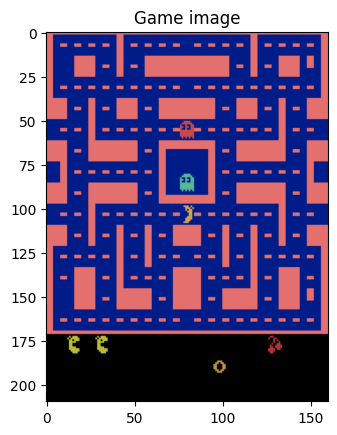

In [6]:
env = gym.make('ALE/MsPacman-v5', frameskip=1, repeat_action_probability=0.0, render_mode='rgb_array')
s = env.reset()
for _ in range(10):
    s, _, _, _, _ = env.step(env.action_space.sample())

plt.title('Game image')
plt.imshow(env.render())
plt.show()

Теперь обернем среду в обертку для проигрывания параллельных игр.

In [7]:
nenv = 8
env = nature_dqn_env('ALE/MsPacman-v5', {'frameskip': 1, 'repeat_action_probability': 0.0}, nenvs=nenv, summaries='Numpy')
obs, info = env.reset()
state_shape = obs.shape
n_actions = env.action_space.n
assert obs.dtype == np.uint8

print('Observation shape:', state_shape)
print('Num actions:', n_actions)

Observation shape: (8, 84, 84, 4)
Num actions: 9


## Теория

Вспомним еще раз, как работает A2C алгоритм.

### Policy Gradient Theorem

$$
\nabla_\theta J(\theta) = \nabla_\theta \sum_{s \in S} d_\pi(s) \sum_{a \in A} \pi_\theta(a|s)Q_\pi(s, a) \propto \sum_{s \in S} d_\pi(s) \sum_{a \in A} Q_\pi(s, a) \nabla_\theta \pi_\theta(a|s).
$$

Тогда, если расписать до конца градиент, то

$$
\begin{align*}
\nabla_\theta J(\theta) &\propto \sum_{s \in S} d_\pi(s) \sum_{a \in A} Q_\pi(s, a) \nabla_\theta \pi_\theta(a|s) \\ &= \sum_{s \in S} d_\pi(s) \sum_{a \in A} \pi_\theta(a|s) Q_\pi(s, a) \dfrac{\nabla_\theta \pi_\theta(a|s)}{\pi_\theta(a|s)} \\ &= \mathsf{E}_{s \sim d_\pi, a \sim \pi_\theta}Q_\pi(s, a) \nabla_\theta \ln\pi_\theta(a|s).
\end{align*}
$$

### A2C
Для уменьшения дисперсии в оценке градиента, придумали заменить $Q(s, a)$ на $A(s, a) = Q(s, a) - V(s)$.

При этом
$$
\mathsf{E}_{s \sim d_\pi, a \sim \pi_\theta}(A_\pi(s, a) \nabla_\theta \ln\pi_\theta(a|s)) \propto \nabla_\theta J(\theta).
$$

Алгоритм, по сравнению с алгоритмом Reinforce, также должен выучивать корректные value-state значения, к примеру, с помощью минимизации $\big[V_\theta(s) - (r + \gamma  V(\widetilde s))\big]^2$, где по $V(\widetilde s)$ градиенты не обновляются.
Также, не обязательно смотреть только на 1 шаг вперед, можно и на $k$, аналогично методу $TD(k)$. В таком случае необходимо минимизировать

$$
L_t = \Bigg[V_\theta(s_t) - \bigg(r_{t+1} + \gamma  \Big(r_{t + 2} + \gamma \big(... [r_{t + k} + \gamma  V(s_{t+k})]\big)\Big)\bigg)\Bigg]^2,
$$

где $V(s_{t+k})$ посчитано агентом.
При этом, можно сыграть агентом на $k$ шагов вперед, а обновлять

$$
\begin{align*}
  L_{t + k - 1} &= \big[V_\theta(s_{t + k - 1}) - \big(r_{t+k} + \gamma  V(s_{t+k})\big)\big]^2, \\
  V'_{t + k - 1} &= r_{t+k} + \gamma  V(s_{t+k}), \\
  L_{t + k - 2} &= \big[V_\theta(s_{t + k - 1}) - \big(r_{t+k} + \gamma  V'_{t + k - 1}\big)\big]^2, \\
  V'_{t + k - 2} &= r_{t+k - 1} + \gamma  V'_{t+k - 1}, \\
  ... \\
  L_{t} &= \big[V_\theta(s_t) - \big(r_{t+1} + \gamma  V'_{t+1})\big)\big]^2, \\
\end{align*}
$$

где $V(s_{t+k})$, и все $V'$ являются константами, по этим параметрам не надо обновлять веса агента, $L_i$ &mdash; value loss на шаге $i$.

__Замечание:__ Если $s_{t + i}$ &mdash; терминальное состояние, то $V'_{t+i+1} = 0$, иначе награды в следующей сессии будут влиять на текущую сессию.

Распишем по шагам алгоритм Advantage Actor-critic:

1. инициализируются параметры $\theta$ модели из рандомного распределения;
2. В цикле по $t=1,2, ... T_{max\_possible}$:
  1. семплируем $r, \widetilde s \sim P(r, \widetilde s|s, a)$;
  2. играем агентом в среде на $k$ шагов вперед, причем здесь это можно делать параллельно, в нескольких сессиях одновременно;
  3. считаем $L_{1},\ ...,\ L_{k}$;
  4. считаем $A_{1},\ ...,\ A_{k}$, т.е. advantage функции;
  5. Обновляются параметры $\theta$:
  $$
  \begin{align*}
  \widehat J &= { 1 \over k } \sum  _{i = 1}^k A_i \log \pi_\theta (a_i | s_i)  \\
  L &= { 1 \over k } \sum  _{i = 1}^k L_{i}\\
  \theta_{t + 1} &= \theta_{t} + \alpha\big(\nabla_\theta \widehat J - \beta \nabla_\theta L\big),
  \end{align*}
  $$
  Где $\beta$ &mdash; вес, с которым надо учитывать вклад $L$ в соотношении с $J$.

*Замечание:* если играть в $N$ игр параллельно, то делить надо не на $k$, а на $k N$.

При этом, чтобы посчитать $A$, не обязательно предсказывать $Q(s, a)$. Можно воспользуемся следующей оценкой,

$$
  Q(s_t, a_t) =  \bigg(r_{t+1} + \gamma  \Big(r_{t + 2} + \gamma  \big(... [r_{t + k} + \gamma  V(s_{t+k})]\big)\Big)\bigg).
$$

То же самое мы делали для нейронных агентов Sarsa, Q-learning, EVSarsa.


----
Теперь реализуем все это!


A2C агент

Ваша первая задача реализовать архитектуру для нейронки агента. Предлагается взять следующую [архитектуру](https://www.dropbox.com/s/yt7zz5at0dgyqpn/Neural_network%20schema.png?dl=0).


**Замечание**  Для нормального обучения также необходимо правильно инициализировать веса у сверточных слоев: воспользуйтесь `nn.init.orthogonal_` с параметром `std`: $\sqrt{2}$, а `bias` инициализируйте 0.

In [8]:
def initialize_weights_in_agent_for_conv_layer(conv_layer, std=np.sqrt(2)):
    nn.init.orthogonal_(conv_layer.weight.data, gain=std)
    nn.init.constant_(conv_layer.bias.data, 0.0)

In [9]:
class A2CAgent(nn.Module):
    def __init__(self, state_shape, n_actions):
        super().__init__()
        self.n_actions = n_actions
        self.state_shape = state_shape

        self.conv_net = nn.Sequential(
            nn.Conv2d(state_shape[-1], 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU(),
            nn.Flatten(),
        )

        self.fc1 = nn.Linear(3136, 512)

        self.actor = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, n_actions),
        )
        
        self.critic = nn.Linear(512, 1)
        self.__init_weights() 

    def forward(self, state_t):
        state_t = state_t.permute(0, 3, 1, 2)  # (B, H, W, C) -> (B, C, H, W)
        conv_out = self.conv_net(state_t)
        fc_out = F.relu(self.fc1(conv_out))
        logits = self.actor(fc_out)
        values = self.critic(fc_out).squeeze(-1)

        return logits, values

    def __init_weights(self):
        """
        Инициализирует веса всех сверточных слоев
        """
        std = np.sqrt(2)
        initialize_weights_in_agent_for_conv_layer(self.conv_net[0], std)
        initialize_weights_in_agent_for_conv_layer(self.conv_net[2], std)
        initialize_weights_in_agent_for_conv_layer(self.conv_net[4], std)

    def act(self, inputs, device=device):
        """
        Сделать шаг агентом.

        Возвращает действия, логиты, логарифм вероятности, V(state).
        actions должен быть np.array, остальные параметры должны иметь градиент.

        Не забудьте привести input к нужной размерности как на рисунке выше.
        Также поделите значения в inputs на 255 (нормировка).

        :param inputs: батч стейтов (изображений) игры
        :param device: torch device
        """

        if isinstance(inputs, np.ndarray):
            inputs = torch.from_numpy(inputs).float().to(device)
        else:
            inputs = inputs.float().to(device)

        logits, values = self.forward(inputs / 255.0)

        dist = Categorical(logits=logits)
        actions_t = dist.sample()
        log_probs = dist.log_prob(actions_t)
        actions = actions_t.cpu().numpy()

        return {
            "actions": actions,
            "logits": logits,
            "log_probs": log_probs,
            "values": values,
        }

    def reset(self):
        """
        Переинициализировать веса
        """
        self.__init_weights()

Проверим что все работает:

In [10]:
agent = A2CAgent(state_shape, n_actions).to(device)
state, info = env.reset()

result_dict = agent.act(state)
print('action logits:\n', result_dict['logits'])
print('state values:\n', result_dict['values'])

action logits:
 tensor([[-0.0213, -0.0209,  0.0496,  0.0675,  0.0456,  0.0273,  0.0704,  0.0788,
         -0.0346],
        [-0.0213, -0.0209,  0.0496,  0.0675,  0.0456,  0.0273,  0.0704,  0.0788,
         -0.0346],
        [-0.0213, -0.0209,  0.0496,  0.0675,  0.0456,  0.0273,  0.0704,  0.0788,
         -0.0346],
        [-0.0213, -0.0209,  0.0496,  0.0675,  0.0456,  0.0273,  0.0704,  0.0788,
         -0.0346],
        [-0.0213, -0.0209,  0.0496,  0.0675,  0.0456,  0.0273,  0.0704,  0.0788,
         -0.0346],
        [-0.0213, -0.0209,  0.0496,  0.0675,  0.0456,  0.0273,  0.0704,  0.0788,
         -0.0346],
        [-0.0213, -0.0209,  0.0496,  0.0675,  0.0456,  0.0273,  0.0704,  0.0788,
         -0.0346],
        [-0.0213, -0.0209,  0.0496,  0.0675,  0.0456,  0.0273,  0.0704,  0.0788,
         -0.0346]], device='cuda:0', grad_fn=<AddmmBackward0>)
state values:
 tensor([0.0196, 0.0196, 0.0196, 0.0196, 0.0196, 0.0196, 0.0196, 0.0196],
       device='cuda:0', grad_fn=<SqueezeBackward1>)


## Env Runner

Следующий шаг &mdash; использовать класс `EnvRunner`, который будет играть агентом на параллельных средах. При этом на каждом шаге он будет возвращать частичную траекторию на `n_steps` шагов вперед, где `n_steps` &mdash; параметр $k$ из формул выше. Кроме того, этому классу можно передать трансформер, который преобразовывает возвращаемую траекторию.

Траектория по умолчанию &mdash; это словарь со следующими значениями:
* `observations`;
* `rewards`;
* `resets`;
* `actions`;
* все остальные значения, возвращаемые методом `act` в `A2CAgent`.

Во всех этих случаях значения &mdash; питоновский лист, хранящий в себе `n_steps` numpy массивов размера `nenvs`. То есть каждое состояние из `n_steps` хранит в себе все статистики для всех параллельных сред. Поэтому размер каждого элемента-массива равен `nenvs`.

Теперь необходимо посчитать
$$
\begin{align*}
  V'_{t + k - 1} &= r_{t+k} + \gamma V(s_{t+k}), \\
  V'_{t + k - 2} &= r_{t+k - 1} + \gamma V'_{t+k - 1}, \\
  ... \\
  V'_{t} &= r_{t + 1} + \gamma V'_{t+1}. \\
\end{align*}
$$

Для этого вам нужно реализовать метод `__call__` у класса ниже. Для этого потребуются следующие величины:
* `trajectory['rewards']` &mdash; награды.
* `trajectory['resets']` &mdash; значение 0 или 1. Если состояние в траектории является терминальным, то соответсвующее $V'$ должно быть 0.
* `trajectory['state']['latest_observation']` &mdash; состояние, на котором в среде остановился агент, или $s_{t+k}$ в формулах выше.

In [11]:
class ComputeValueTargets:
    def __init__(self, agent, gamma=0.99):
        self.agent = agent
        self.gamma = gamma

    def __call__(self, trajectory, device=device):
        """
        Этот метод должен добавить в словарь trajectory
        новый элемент value_targets, в котором будут храниться V'.

        :param trajectory: описанный выше словарь траекторий
        :param device: torch device
        """
        last_state = trajectory["state"]["latest_observation"]
        act_dict = self.agent.act(last_state)
        values = act_dict["values"].detach().to(device)

        rewards = [
            torch.tensor(r, dtype=torch.float32, device=device)
            for r in trajectory["rewards"]
        ]
        resets = [
            torch.tensor(r, dtype=torch.float32, device=device)
            for r in trajectory["resets"]
        ]

        mask = 1.0 - resets[-1]
        delta = rewards[-1] + self.gamma * values * mask

        value_targets = []
        for t in reversed(range(len(rewards))):
            mask = 1.0 - resets[t]
            delta = rewards[t] + self.gamma * delta * mask
            value_targets.append(delta)

        value_targets.reverse()

        trajectory["value_targets"] = torch.stack(value_targets, dim=0)
        trajectory["value_targets"] = trajectory["value_targets"].reshape(-1)

Проверим, что все запускается.

In [12]:
runner = EnvRunner(env, agent, nsteps=5,
                   transforms=[ComputeValueTargets(agent)])

In [13]:
trajectory = runner.get_next()

Теперь возникает следующая проблема: каждое значение в словаре траектории имеет размер (`n_steps`, `nenvs`), что неудобно, поскольку `batch_size` в таком виде имеет двумерную размерность. Поэтому предлагается сконкатенировать массивы, чтобы итоговый `batch_size` равнялся `n_steps` $\times$ `nenvs`.

In [14]:
class MergeTimeBatch:
    """Класс для склеивания первых 2 размерности траектории."""

    def __init__(self, nsteps):
        self.nsteps = nsteps

    def __call__(self, trajectory):
        """
        Проходит по всем значениям из словаря trajectory и склеивает первые две размерности в одну

        :param trajectory: словарь траекторий
        """
        # Modify trajectory inplace.
        for key in trajectory:
            if (
                not isinstance(trajectory[key], list)
                or len(trajectory[key]) != self.nsteps
            ):
                continue
            if torch.is_tensor(trajectory[key][0]):
                trajectory[key] = torch.cat(trajectory[key], dim=0)
            else:
                trajectory[key] = np.concatenate(trajectory[key], axis=0)

Снова проверим, что все отрабатывает корректно.

In [15]:
runner = EnvRunner(env, agent, nsteps=5,
                   transforms=[ComputeValueTargets(agent),
                               MergeTimeBatch(nsteps=5)])

In [16]:
trajectory = runner.get_next()

nsteps = 5
correct_size_keys = set()
for key in trajectory:
    if len(trajectory[key]) == nsteps * state_shape[0]:
        correct_size_keys.add(key)        

assert correct_size_keys == {'actions', 'log_probs', 'logits', 'observations',
      'resets', 'rewards', 'value_targets', 'values'}, \
      'Sorry not all elements are concatenated correctly'

## Actor-critic policy класс

Теперь осталось написать класс-обертку над агентом, который будет считать лосс и выдавать словарь с интресующими нас значениями метрик обучения.

Напомним, какие нас интересуют loss-функции.

__Policy loss__

Вспомним формулу, выведенную на лекции:
$$ \widehat J = { 1 \over k N } \sum  _{i = 1}^{k N} \gamma^{n_i} A_i \log \pi_\theta (a_i | s_i) , \\
A_i = V'_i - V_i,
$$

где
- $A$ &mdash; константа, по которой градиент не обновляется,
- $n_i$ &mdash; количество шагов с начала сессии.

В этой формуле в каждом слагаемом есть множитель $\gamma^{n_i}$. Часто на практике его опускают, чтобы одинаково учитывать действия на разных шагах алгоритма. Иначе в целом шаги градиентного спуска по действиям в начале траектории будут больше шагов по действиям в конце траектории, и значимо больше, если траектории длинные.
В данной задаче так же предлагается опустить эти множители. Поэтому итоговая формула, которую будем использовать в алгоритме:

$$ \widehat J = { 1 \over k N } \sum  _{i = 1}^{k N}A_i \log \pi_\theta (a_i | s_i)
$$


__Value loss__

  $$ L = { 1 \over k N } \sum_{i = 1}^{k N} L_i,\\
     L_{i} = (V'_i - V_i) ^ 2 $$

__Entropy Regularizer__
  $$ H = - {1 \over k N} \sum  _{s_i,a_i} \pi_\theta (a_i | s_i) \log \pi_\theta (a_i | s_i).$$
  
Для того, чтобы обучение не сошлось преждевременно, поощрение за exploration.

---
**A2C loss:** $- \widehat J + \beta L - \kappa H$.

Теперь реализуем класс-обертку `A2CPolicy`, который будет хранить внутри себя агента и обновлять его веса.

In [17]:
def to_one_hot(y, n_dims=None):
    '''
    Конвертирует массив значений в one-hot матрицу.
    
    :param y: целочисленный tensor
    :param n_dims: количество классов в y
    '''

    y_tensor = y.to(dtype=torch.int64).view(-1, 1)
    n_dims = n_dims if n_dims is not None else int(torch.max(y_tensor)) + 1
    y_one_hot = torch.zeros(y_tensor.size()[0], n_dims, device=device).scatter_(1, y_tensor, 1)
    return y_one_hot


In [18]:
class A2CPolicy:
    def __init__(
        self,
        agent,
        optimizer,
        value_loss_coef=0.25,
        entropy_coef=0.01,
        max_grad_norm=0.5,
    ):
        """
        Инициализация класса.

        :param agent: агент, который учится в среде
        :param optimizer: оптимизатор для обучения агента
        :param value_loss_coef: параметр beta в формуле выше
        :param entropy_coef: параметр gamma в формуле выше
        :param max_grad_norm: максимальная норма градиента (для clipping)
        """

        self.agent = agent
        self.optimizer = optimizer
        self.value_loss_coef = value_loss_coef
        self.entropy_coef = entropy_coef
        self.max_grad_norm = max_grad_norm
    
    def policy_loss(self, trajectory):
        """
        Нужно посчитать J_hat. Все необходимое хранится в trajectory.

        :param trajectory: словарь траекторий
        """
        V = trajectory["values"]
        log_probs = trajectory["log_probs"]
        A = trajectory["value_targets"] - V
        J_hat = (log_probs * A.detach()).mean()
        return J_hat

    def value_loss(self, trajectory):
        """
        Нужно посчитать L (value loss). Все необходимое хранится в trajectory.

        :param trajectory: словарь траекторий
        """

        act_dict = self.agent.act(trajectory["observations"])
        V = act_dict["values"]

        val_loss = torch.mean((trajectory["value_targets"] - V) ** 2)

        return val_loss

    def entropy_loss(self, trajectory):
        """
        Нужно посчитать L (entropy loss). Все необходимое хранится в trajectory.

        :param trajectory: словарь траекторий
        """

        act_dict = self.agent.act(trajectory["observations"])
        logits = act_dict["logits"]                     # [nsteps*nenvs, n_actions]
        probs = F.softmax(logits, dim=-1)
        log_probs = F.log_softmax(logits, dim=-1)
        entropy_loss = -(probs * log_probs).sum(dim=-1).mean()

        return entropy_loss

    def loss(self, trajectory):
        """
        Нужно посчитать полный loss для A2C.
        Вызывает внутри себя policy_loss, value_loss, entropy_loss.

        :param trajectory: словарь траекторий
        """

        policy_loss = self.policy_loss(trajectory)
        value_loss = self.value_loss(trajectory)
        entropy_loss = self.entropy_loss(trajectory)

        loss = -policy_loss + self.value_loss_coef * value_loss - self.entropy_coef * entropy_loss

        return loss, policy_loss, value_loss, entropy_loss

    def step(self, trajectory):
        """
        Считает текущий loss, обновляет веса агента, используя gradient clipping.
        Возвращает словарь с текущими метриками для последующей визуализации.
        """
        loss, policy_loss, value_loss, entropy_loss = self.loss(trajectory)
        self.optimizer.zero_grad()
        loss.backward()
        grad_norm = torch.nn.utils.clip_grad_norm_(
            self.agent.parameters(), self.max_grad_norm
        )
        self.optimizer.step()
    
        metrics_dict = {
            "loss": loss.item(),
            "policy loss": policy_loss.item(),
            "entropy loss": entropy_loss.item(),
            "value loss": value_loss.item(),
            "Grad norm": grad_norm,
        }
        return metrics_dict

## Обучение

Чтобы модель сходилась лучше, воспользуемся линейным уменьшением шага `learning_rate` в `optimizer`.

In [19]:
class LinearScheduller:
    def __init__(self, optimizer, max_num_iters, start_lr=7 * 10 ** -4, end_lr=0):
        '''
        Линейно уменьшает learning_rate в optimizer с start_lr до end_lr за max_num_iters итераций
        '''
        self.optimizer = optimizer
        self.max_num_iters = max_num_iters
        self.start_lr = start_lr
        self.end_lr = end_lr
        self.curr_iter = 0


    def step(self):
        '''
        Делает один шаг уменьшения learning_rate
        '''
        self.curr_iter += 1
        curr_lr = (self.start_lr * (self.max_num_iters - self.curr_iter)\
                   + self.end_lr * self.curr_iter) / self.max_num_iters

        for param_group in self.optimizer.param_groups:
            param_group['lr'] = curr_lr


Теперь проинициализируем `A2CPolicy`.

In [20]:
agent = A2CAgent(state_shape, n_actions).to(device)
runner = EnvRunner(env, agent, nsteps=5,
                   transforms=[ComputeValueTargets(agent),
                               MergeTimeBatch(nsteps=5)])

start_lr = 7e-4
total_steps= int(1e7 / (40))
optimizer = torch.optim.RMSprop(agent.parameters(), lr=start_lr, alpha=0.99, eps=1e-5)

# Линейный шедуллер весов
scheduler = LinearScheduller(optimizer, max_num_iters=total_steps,
                             start_lr=start_lr, end_lr=0)
a2c_policy = A2CPolicy(agent, optimizer)

runner.reset()

Функция для подсчета награды в обернутом environment.

In [21]:
def eval_mean_reward(env, nenv):
    '''
    Функция для корректного подсчета награды за одну игру целиком,
    то есть за 3 жизни Pacman.
    Средняя на параллельных играх.
    '''

    return np.mean([np.mean(queue) for queue in env.get_wrapper_attr('reward_queues')])


Время обучения модели в Collab на GPU занимает 5 часов, так что можете теперь расслабиться и наблюдать за изменением награды 🐱

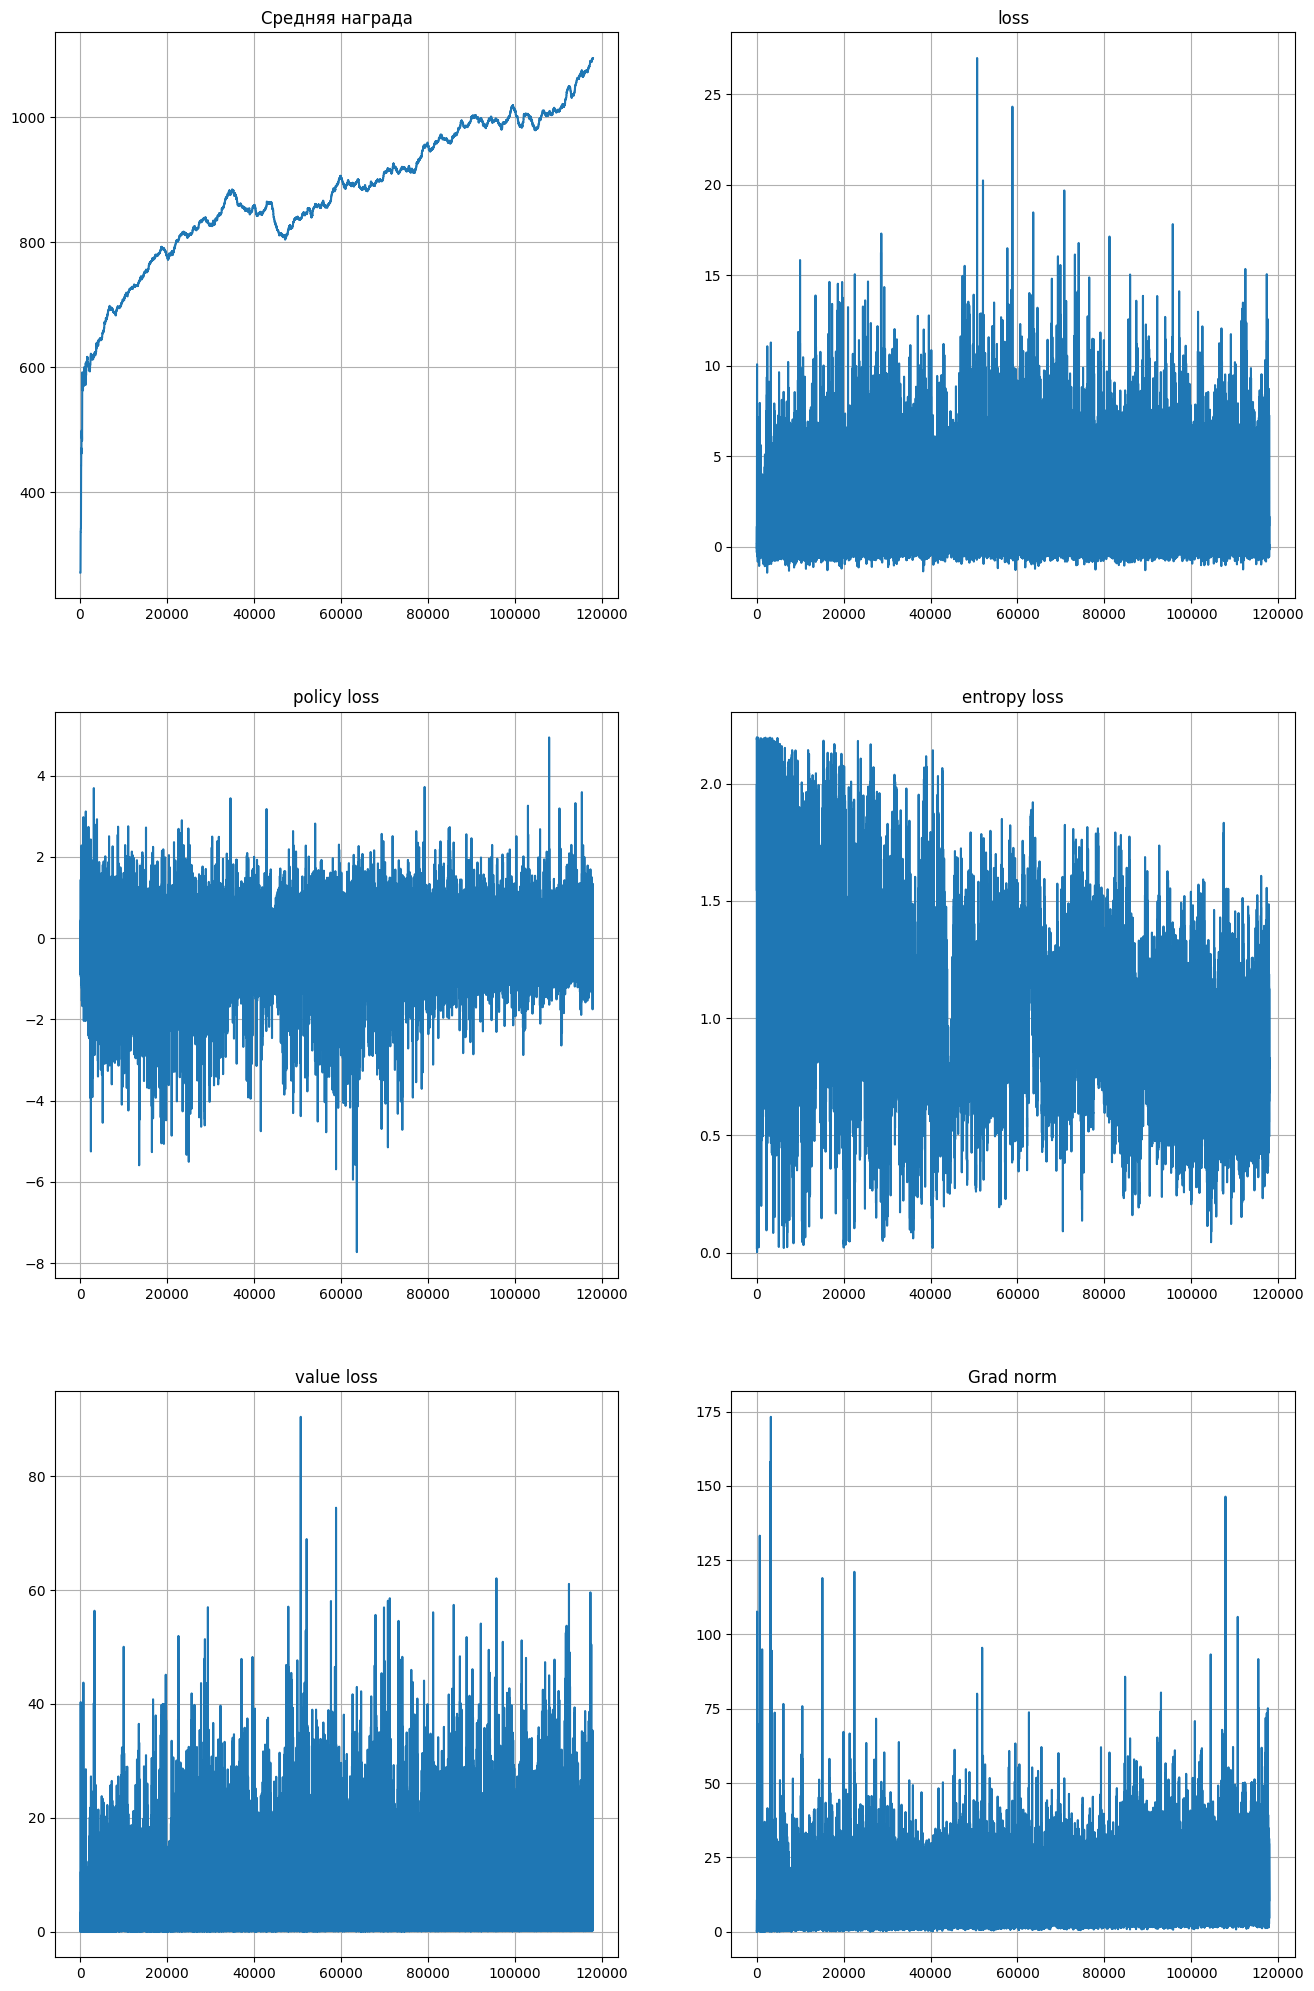

 47%|████▋     | 118322/250001 [2:10:52<2:25:39, 15.07it/s]

Ты победил!


In [22]:
metrics_dict_history = defaultdict(list)

for step in trange(0, total_steps + 1, leave=True):

    trajectory = runner.get_next()
    metrics_dict = a2c_policy.step(trajectory)
    scheduler.step()

    if step > 50:
        for key, value in metrics_dict.items():
            if torch.is_tensor(value):
                metrics_dict_history[key].append(value.detach().cpu().item())
            else:
                metrics_dict_history[key].append(value)

    metrics_dict_history['Средняя награда'].append(
        float(eval_mean_reward(env, 8))
    )

    if np.mean(metrics_dict_history['Средняя награда'][-100:]) > 1100:
        print('Ты победил!')
        break

    if step % 1000 == 999:
        gc.collect()
        clear_output(True)

        plt.figure(figsize=[16, 25])
        for index, key in enumerate(metrics_dict_history):
            plt.subplot(3, 2, index + 1)
            plt.title(key)
            plt.plot(metrics_dict_history[key])
            plt.grid()
        plt.show()

Теперь посмотрим, как в реальности обучился алгоритм играть в Pacman!

In [23]:
from atari_wrappers import MaxBetweenFrames, SkipFrames, ImagePreprocessing, QueueFrames
env = gym.make('ALE/MsPacman-v5', frameskip=1, repeat_action_probability=0.0, render_mode='rgb_array')
env.set_wrapper_attr('seed', None)

def make_env_for_evaluation(env):
    env = SkipFrames(env, 4)
    env = MaxBetweenFrames(env)
    env = ImagePreprocessing(env, width=84, height=84, grayscale=True)
    env = QueueFrames(env, 4)
    return env

env = make_env_for_evaluation(env)

In [24]:
def evaluate(agent, env, env_monitor, n_games=1):
    '''
    Играет 1 полную сессию агентом.

    :param agent: агент
    :param env: окружение gymnasium
    :param env_monitor: мониторинг для сохранения стейтов для видео
    :param n_games: количество игр
    '''

    game_rewards = []
    for _ in range(n_games):
        observation, info = env_monitor.reset()
        total_reward = 0
        while True:
            # env_monitor.capture_frame()
            act = agent.act(observation[None, ...])
            observation, reward, done, truncated, info = env_monitor.step(act['actions'][0])
            total_reward += reward
            if done:
                break

        game_rewards.append(total_reward)
    return game_rewards


In [25]:
import os
import shutil
import numpy as np
import gym
from gym.wrappers import RecordVideo

# Папка для видео
video_folder = './videos'
os.makedirs(video_folder, exist_ok=True)
final_video_name = 'video.mp4'

# Создаём среду с записью видео
env_monitor = RecordVideo(
    env,
    video_folder=video_folder,
    episode_trigger=lambda episode_id: True  # записываем все эпизоды
)

# Запускаем оценку агента
rewards = evaluate(agent, env, env_monitor, n_games=8)

env_monitor.close()
env.close()

# Берём последний созданный файл и переименовываем
video_files = sorted(os.listdir(video_folder))
if video_files:
    last_video = os.path.join(video_folder, video_files[-1])
    final_video_path = os.path.join(video_folder, final_video_name)
    shutil.move(last_video, final_video_path)
    print(f'Видео сохранено как {final_video_path}')

print('Награды:', rewards)
print('Средняя награда:', np.mean(rewards))

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/gym/wrappers/record_video.py:75: UserWarning: WARN: Overwriting existing videos at /kaggle/working/videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


Moviepy - Building video /kaggle/working/videos/rl-video-episode-0.mp4.
Moviepy - Writing video /kaggle/working/videos/rl-video-episode-0.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/videos/rl-video-episode-0.mp4
Moviepy - Building video /kaggle/working/videos/rl-video-episode-1.mp4.
Moviepy - Writing video /kaggle/working/videos/rl-video-episode-1.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/videos/rl-video-episode-1.mp4
Moviepy - Building video /kaggle/working/videos/rl-video-episode-2.mp4.
Moviepy - Writing video /kaggle/working/videos/rl-video-episode-2.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/videos/rl-video-episode-2.mp4
Moviepy - Building video /kaggle/working/videos/rl-video-episode-3.mp4.
Moviepy - Writing video /kaggle/working/videos/rl-video-episode-3.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/videos/rl-video-episode-3.mp4
Moviepy - Building video /kaggle/working/videos/rl-video-episode-4.mp4.
Moviepy - Writing video /kaggle/working/videos/rl-video-episode-4.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/videos/rl-video-episode-4.mp4
Moviepy - Building video /kaggle/working/videos/rl-video-episode-5.mp4.
Moviepy - Writing video /kaggle/working/videos/rl-video-episode-5.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/videos/rl-video-episode-5.mp4
Moviepy - Building video /kaggle/working/videos/rl-video-episode-6.mp4.
Moviepy - Writing video /kaggle/working/videos/rl-video-episode-6.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/videos/rl-video-episode-6.mp4
Moviepy - Building video /kaggle/working/videos/rl-video-episode-7.mp4.
Moviepy - Writing video /kaggle/working/videos/rl-video-episode-7.mp4



Moviepy - Done !
Moviepy - video ready /kaggle/working/videos/rl-video-episode-7.mp4
Видео сохранено как ./videos/video.mp4
Награды: [1530.0, 1270.0, 1020.0, 710.0, 700.0, 1030.0, 570.0, 720.0]
Средняя награда: 943.75


Отлично, ты обучил нейронку играть в настоящую игру!

Запись игры: https://disk.360.yandex.ru/i/SKaNF7LN29Xz3g